# Latent DDNM (scratch) — SD1.5 + SPNN-512

Drives the **clean-room latent DDNM** in `DDNM-main-scartch/` (the new version),
not the old `DDNM-main/` attempt. Mirrors `app.ipynb`: codec setup, the
**100-cycle codec-consistency** plot (SPNN's near-invertibility vs the lossy VAE),
then the **first inpainting** run with per-step restoration **GIFs**.

Latent DDNM step:
`z0 -> x0=D(z0) -> x0_hat = x0 - A^+(A x0 - y) -> z0_hat=E(x0_hat) -> DDIM`,
so data-consistency is exact in pixel space and only as good as `E(D(.))` — which
is exactly why the codec-cycle behaviour below matters. Run inside the pytorch
container (torch + diffusers + transformers; SD1.5 in `$HF_HOME`).

In [1]:
import os, sys
from pathlib import Path

# Run from the scratch DDNM folder (matches how main.py runs: configs/ + repo_root="..").
# DDNM_ROOT = Path("/shared/cycle1_iit_shocher_prj/ron/spnn/simple-latent-diffusion-model/DDNM-main-scartch")
DDNM_ROOT = Path("/home/ron.libman/simple-latent-diffusion-model-nebius/DDNM-main-scratch")
os.chdir(DDNM_ROOT)
sys.path.insert(0, str(DDNM_ROOT))

# SD1.5 loads offline from the shared HF cache (its Hub repo was removed).
os.environ.setdefault("HF_HOME", "/shared/cycle1_iit_shocher_prj/ron/hf_cache")
os.environ.setdefault("HF_HUB_OFFLINE", "1")
os.environ.setdefault("TRANSFORMERS_OFFLINE", "1")

import torch, numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| cwd:", Path.cwd())

/home/ron.libman/.local/lib/python3.8/site-packages/torch/onnx/_internal/_beartype.py:30: UserWarning: module 'beartype.roar' has no attribute 'BeartypeDecorHintPep585DeprecationWarning'
  warnings.warn(f"{e}")


device: cuda | cwd: /home/ron.libman/simple-latent-diffusion-model-nebius/DDNM-main-scratch


In [2]:
# --- config (the new latent DDNM config) ---
import argparse, yaml

def dict2namespace(d):
    ns = argparse.Namespace()
    for k, v in d.items():
        setattr(ns, k, dict2namespace(v) if isinstance(v, dict) else v)
    return ns

config = dict2namespace(yaml.safe_load(open("configs/sd15_inpaint_latent.yml")))
IMAGE_SIZE = int(config.data.image_size)
print("model.type :", config.model.type)
print("codec.type :", config.codec.type, "| spnn:", config.codec.spnn_checkpoint)
print("image size :", IMAGE_SIZE, "-> latent (4,", IMAGE_SIZE // 8, ",", IMAGE_SIZE // 8, ")")

model.type : latent_sd15
codec.type : spnn | spnn: runs/spnn512_sd15_distill/ckpt_last.pt
image size : 512 -> latent (4, 64 , 64 )


In [3]:
import os
# Force HF to use your local home directory for storage
os.environ["HF_HOME"] = os.path.expanduser("~/.cache/huggingface")

# Keep these from before to ensure online mode stays active
os.environ["HF_HUB_OFFLINE"] = "0"
os.environ["TRANSFORMERS_OFFLINE"] = "0"
os.environ["HF_DATASETS_OFFLINE"] = "0"

# --- SD1.5 prior: UNet + analytic scaled_linear schedule + null (empty-prompt) embedding ---
from diffusers import UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer
from functions.latent_ddnm import sd15_alphas_cumprod, make_alpha_bar

SD_ID = config.model.sd15_id

unet = UNet2DConditionModel.from_pretrained(SD_ID, subfolder="unet", local_files_only=False).to(device).eval()
unet.requires_grad_(False)

alphas_cumprod = sd15_alphas_cumprod(
    num_train_timesteps=int(config.diffusion.num_diffusion_timesteps),
    beta_start=float(config.diffusion.beta_start),
    beta_end=float(config.diffusion.beta_end),
    device=device,
)
alpha_bar = make_alpha_bar(alphas_cumprod)

tok = CLIPTokenizer.from_pretrained(SD_ID, subfolder="tokenizer")
te = CLIPTextModel.from_pretrained(SD_ID, subfolder="text_encoder").to(device).eval()
with torch.no_grad():
    ids = tok([""], padding="max_length", max_length=tok.model_max_length,
              return_tensors="pt").input_ids.to(device)
    null_emb = te(ids)[0]
print("UNet + schedule + null embedding ready:", tuple(null_emb.shape))

/home/ron.libman/.local/lib/python3.8/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


UNet + schedule + null embedding ready: (1, 77, 768)


In [4]:
# --- codecs: SD KL-VAE and SPNN-512 (both encode/decode in SD's scaled latent space) ---
from functions.latent_codec import load_vae, load_spnn

vae_codec = load_vae(device)
spnn_codec = load_spnn(config, device)
codecs = {"VAE": vae_codec, "SPNN": spnn_codec}
print("codecs:", list(codecs))

Loading SD1.5 VAE (runwayml/stable-diffusion-v1-5)...
Loading SPNN-512 from /home/ron.libman/simple-latent-diffusion-model-nebius/runs/spnn512_sd15_distill/ckpt_last.pt...
codecs: ['VAE', 'SPNN']


In [5]:
# --- helpers + test images (cycle helpers mirror app.ipynb) ---
import glob
from PIL import Image
from torchvision import transforms

def psnr(a, b):
    """PSNR per image in the [-1,1] domain (peak^2 = 4). Returns [B]."""
    mse = (a.clamp(-1, 1) - b).pow(2).flatten(1).mean(1)
    return 10 * torch.log10(4.0 / mse.clamp_min(1e-12))

def to01(x):   return x.clamp(-1, 1) * 0.5 + 0.5
def to_img(t): return to01(t).cpu().permute(1, 2, 0).numpy()   # single image [3,H,W] -> [H,W,3]

@torch.no_grad()
def vae_cycle(x):  return vae_codec.decode(vae_codec.encode(x))    # one encode->decode round-trip
@torch.no_grad()
def spnn_cycle(x): return spnn_codec.decode(spnn_codec.encode(x))

tf = transforms.Compose([
    transforms.Resize(IMAGE_SIZE, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3),   # -> [-1, 1]
])
def load(p): return tf(Image.open(p).convert("RGB"))

img_paths = sorted(p for p in glob.glob("exp/datasets/imagenet/**/*", recursive=True)
                   if p.lower().endswith((".jpeg", ".jpg", ".png")) and ".ipynb_checkpoints" not in p)
print(f"{len(img_paths)} test images")

x = load(img_paths[0])[None].to(device)
with torch.no_grad():
    for name, cyc in [("VAE", vae_cycle), ("SPNN", spnn_cycle)]:
        print(f"  {name:5s}: 1-cycle round-trip {psnr(cyc(x), x)[0].item():5.2f} dB")

8 test images
  VAE  : 1-cycle round-trip 30.86 dB
  SPNN : 1-cycle round-trip 32.60 dB


## Codec consistency over 100 encode–decode cycles

The SPNN thesis: a near-invertible codec barely drifts when you traverse it
repeatedly, while the lossy KL-VAE degrades. This is what makes the per-step
`decode -> pin -> encode` data-consistency safe in latent DDNM. (Mirrors `app.ipynb`.)

SD1.5 VAE: cycle 1 = 29.06 dB, cycle 100 = 7.08 dB
SPNN     : cycle 1 = 31.23 dB, cycle 100 = 31.23 dB


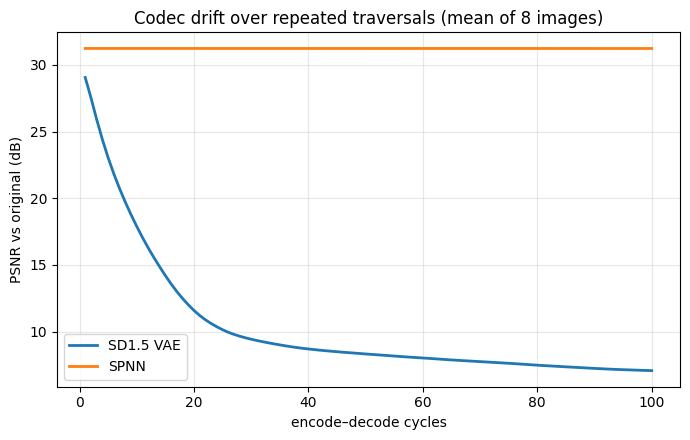

In [7]:
# --- 100-cycle codec drift (mean PSNR over the test set) ---
N, CYCLES = min(20, len(img_paths)), 100
xb = torch.stack([load(p) for p in img_paths[:N]]).to(device)   # [N,3,512,512]

curves = {}
with torch.no_grad():
    for name, fn in [("SD1.5 VAE", vae_cycle), ("SPNN", spnn_cycle)]:
        x, ps = xb.clone(), []
        for c in range(1, CYCLES + 1):
            x = fn(x)
            ps.append(psnr(x, xb).mean().item())
        curves[name] = ps
        print(f"{name:9s}: cycle 1 = {ps[0]:.2f} dB, cycle 100 = {ps[-1]:.2f} dB")

plt.figure(figsize=(7, 4.5))
for name, ps in curves.items():
    plt.plot(range(1, CYCLES + 1), ps, label=name, linewidth=2)
plt.xlabel("encode–decode cycles"); plt.ylabel("PSNR vs original (dB)")
plt.title(f"Codec drift over repeated traversals (mean of {N} images)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

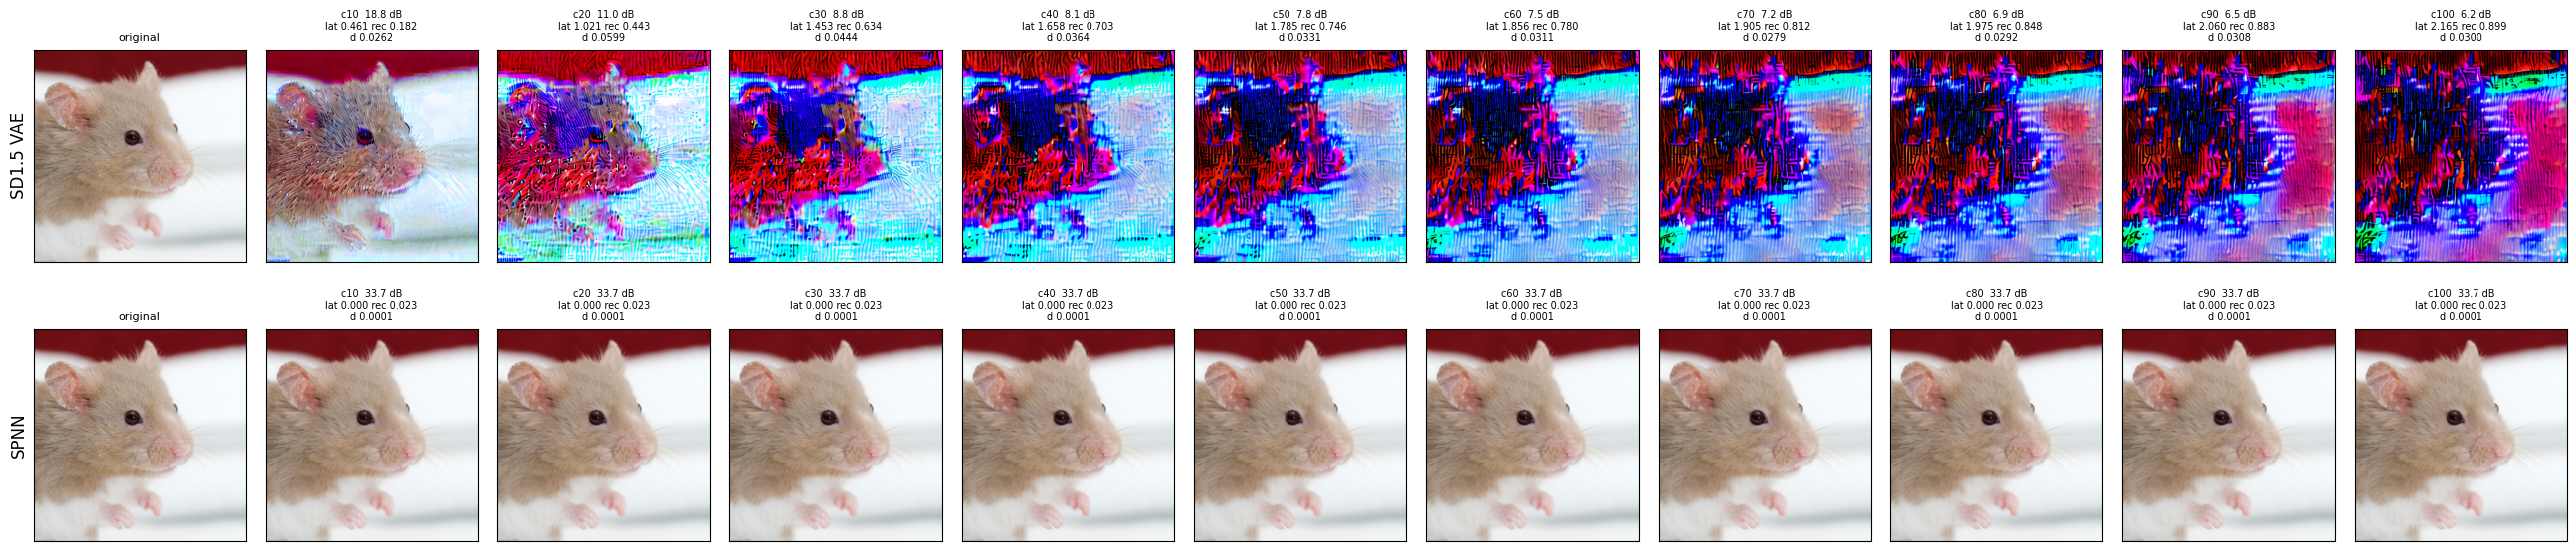

In [8]:
# --- single-image cycle snapshots (10,20,...,100) with per-cycle losses (mirrors app.ipynb) ---
x0 = load(img_paths[1])[None].to(device)
snap_at = list(range(10, 101, 10))

rows = {}
with torch.no_grad():
    for name, cyc, enc in [("SD1.5 VAE", vae_cycle, vae_codec.encode),
                           ("SPNN", spnn_cycle, spnn_codec.encode)]:
        z0 = enc(x0)
        x, x_prev, snaps = x0.clone(), x0.clone(), []
        for c in range(1, 101):
            x_prev, x = x, cyc(x)
            if c in snap_at:
                lat  = torch.nn.functional.mse_loss(enc(x), z0).item()
                rec  = torch.nn.functional.l1_loss(x, x0).item()
                step = torch.nn.functional.l1_loss(x, x_prev).item()
                snaps.append((c, x.clone(), lat, rec, step))
        rows[name] = snaps

fig, axes = plt.subplots(2, 11, figsize=(26, 6))
for r, (name, snaps) in enumerate(rows.items()):
    axes[r, 0].imshow(to_img(x0[0])); axes[r, 0].set_title("original", fontsize=8)
    axes[r, 0].set_ylabel(name, fontsize=12)
    for ci, (c, xc, lat, rec, step) in enumerate(snaps, start=1):
        axes[r, ci].imshow(to_img(xc[0]))
        axes[r, ci].set_title(f"c{c}  {psnr(xc, x0)[0].item():.1f} dB\nlat {lat:.3f} rec {rec:.3f}\nd {step:.4f}",
                              fontsize=7)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## First inpainting run (with restoration GIFs)

VAE vs SPNN under identical sampling (unconditional, T=100), with the λ-schedule +
damping knobs in the cell. Each run saves per-step GIFs (`x0` and `x0_hat`). Tweak
`LAMBDA_MODE` / `LAMBDA_RATE` / `LAMBDA_FLOOR` at the top of the cell.

In [6]:
# --- inpainting mask: use the staged file exp/inp_masks/mask.npy (1=known, 0=hole) ---
from functions.latent_ddnm import load_mask_file, make_inpaint_mask

MASK_PATH = "exp/inp_masks/mask.npy"      # the mask currently in the dir (resized to IMAGE_SIZE)
if os.path.exists(MASK_PATH):
    mask = load_mask_file(MASK_PATH, IMAGE_SIZE, device=device)
    print(f"loaded {MASK_PATH} -> {tuple(mask.shape)} | missing {1 - mask.mean().item():.1%}")
else:
    mask = make_inpaint_mask(IMAGE_SIZE, kind=config.inpainting.mask_kind,
                             box_frac=float(config.inpainting.mask_box_frac), device=device)
    print(f"generated '{config.inpainting.mask_kind}' mask | missing {1 - mask.mean().item():.1%}")

A  = lambda u: mask * u          # degradation: keep known pixels
Ap = lambda r: mask * r          # A^+ of a 0/1 projection is itself

loaded exp/inp_masks/mask.npy -> (1, 1, 512, 512) | missing 26.1%


In [10]:
# --- FIRST INPAINTING CELL: latent DDNM, VAE then SPNN, with restoration GIFs ---
from functions.latent_ddnm import latent_ddnm_sample
from PIL import Image as PILImage
from IPython.display import Image as IPyImage, display

IMG_IDX      = 2
T_SAMPLING   = 200 #int(config.time_travel.T_sampling) = 200
ETA          = 0.85
LAMBDA_MODE  = "const"      # const=1 keeps the known region pinned (no background drift); decay only releases it
LAMBDA_RATE  = 1.0       # exp-decay tempo (higher = faster drop-off)
LAMBDA_FLOOR = 0.1       # lambda decays toward this
latent_shape = (1, 4, IMAGE_SIZE // 8, IMAGE_SIZE // 8)

gif_dir = Path("exp/image_samples/app_scratch_gifs/original"); gif_dir.mkdir(parents=True, exist_ok=True)
def save_gif(frames, path, total_ms=5000):
    pil = [PILImage.fromarray(f) for f in frames]
    if not pil:
        return
    pil[0].save(path, save_all=True, append_images=pil[1:],
                duration=max(1, total_ms // len(pil)), loop=0)

x_orig = load(img_paths[IMG_IDX])[None].to(device)   # [-1, 1]
y = A(x_orig)                                          # masked measurement (known pixels)

recons, gifs = {}, {}
for name, codec in codecs.items():
    frames_x0, frames_hat = [], []
    def hook(i, x0, x0_hat, F0=frames_x0, FH=frames_hat):
        F0.append((to_img(x0[0]) * 255).astype("uint8"))                      # raw decode (bg flickers)
        comp = mask * x_orig + (1.0 - mask) * x0                              # final_known_pin per frame
        FH.append((to_img(comp[0]) * 255).astype("uint8"))                    # exact original bg + evolving hole
    g = torch.Generator(device=device).manual_seed(1234)
    x_rec = latent_ddnm_sample(
        unet, codec, alpha_bar, null_emb, A, Ap, y,
        T_sampling=T_SAMPLING, num_train_timesteps=alphas_cumprod.numel(),
        eta=ETA, lambda_mode=LAMBDA_MODE, lambda_rate=LAMBDA_RATE, lambda_floor=LAMBDA_FLOOR,
        guidance_scale=1.0, context_uncond=None,
        latent_shape=latent_shape, device=device, generator=g, record_hook=hook,
    )
    # final_known_pin: force the unmasked region to be EXACTLY the original (pixel composite).
    # Hole (mask==0) stays as the latent-DDNM output; known region (mask==1) <- x_orig, bit-exact.
    x_rec = mask * x_orig + (1.0 - mask) * x_rec
    recons[name] = x_rec
    save_gif(frames_x0, gif_dir / f"x0_{name}.gif")
    gp = gif_dir / f"x0hat_{name}.gif"; save_gif(frames_hat, gp); gifs[name] = gp
    print(f"{name:5s} PSNR = {psnr(x_rec, x_orig)[0].item():.2f} dB | gif -> {gp}")

# static panel: original | masked | recons
panels = [("original", x_orig), ("masked", y)] + [(f"{k} recon", v) for k, v in recons.items()]
fig, ax = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
for a, (title, im) in zip(ax, panels):
    a.imshow(to_img(im[0])); a.set_title(title); a.axis("off")
plt.tight_layout()
fig.savefig(gif_dir / "result_panel.png", dpi=150, bbox_inches="tight")          # comparison panel
for _k, _v in recons.items():                                                     # final recon per codec (known region = original)
    PILImage.fromarray((to_img(_v[0]) * 255).astype("uint8")).save(gif_dir / f"recon_{_k}.png")
print(f"saved result_panel.png + recon_*.png -> {gif_dir}")
plt.show()

# animated restoration (x0_hat per step) per codec
for name, gp in gifs.items():
    print(f"{name} restoration (x0_hat per step):")
    display(IPyImage(filename=str(gp)))

### Mask: center box (smaller — 128×128, ~6% hole) — same settings as the main cell

In [11]:
# --- Mask: CENTER -- reuses the EXACT settings from the main inpainting cell ---
# (run the main inpainting cell above first: it defines LAMBDA_MODE/RATE/FLOOR, ETA, save_gif, ...)
import torch
from functions.latent_ddnm import make_inpaint_mask
mask = make_inpaint_mask(IMAGE_SIZE, kind="box", box_frac=0.4, device=device)   # centered 128x128 hole (half the side of the old 0.5 box)
A  = lambda u: mask * u
Ap = lambda r: mask * r

x_orig = load(img_paths[4])[None].to(device)
y = A(x_orig)
gif_dir = Path("exp/image_samples/app_scratch_gifs/center"); gif_dir.mkdir(parents=True, exist_ok=True)
# --- center mask = ONE big contiguous hole: override the global schedule, this cell only ---
C_LAMBDA_MODE = "exp"   # const lambda=1: keep the boundary known-region pinned (no decay -> interior gets clean context)
C_TRAVEL_LEN  = 1        # RePaint time-travel jump length (1 = off)
C_TRAVEL_REP  = 1         # resampling passes per jump. NOTE: runtime ~ x(1 + 2*LEN*(REP-1)*njumps/T) -- here ~8x slower
print(f"[center] missing {1 - mask.mean().item():.1%} | lambda={C_LAMBDA_MODE} (override) "
      f"travel={C_TRAVEL_LEN}x{C_TRAVEL_REP} eta={ETA} T={T_SAMPLING}")

recons, gifs = {}, {}
for name, codec in codecs.items():
    frames_x0, frames_hat = [], []
    def hook(i, x0, x0_hat, F0=frames_x0, FH=frames_hat):
        F0.append((to_img(x0[0]) * 255).astype("uint8"))                      # raw decode (bg flickers)
        comp = mask * x_orig + (1.0 - mask) * x0                              # final_known_pin per frame
        FH.append((to_img(comp[0]) * 255).astype("uint8"))                    # exact original bg + evolving hole
    g = torch.Generator(device=device).manual_seed(1234)
    x_rec = latent_ddnm_sample(
        unet, codec, alpha_bar, null_emb, A, Ap, y,
        T_sampling=500, num_train_timesteps=alphas_cumprod.numel(),
        eta=ETA, lambda_mode=C_LAMBDA_MODE, lambda_val=1.0, lambda_floor=0.1,          # const lambda=1 (override the global decay)
        travel_length=C_TRAVEL_LEN, travel_repeat=C_TRAVEL_REP,        # RePaint time-travel for the big interior
        guidance_scale=1.0, context_uncond=None,
        latent_shape=latent_shape, device=device, generator=g, record_hook=hook,
    )
    # final_known_pin: force the unmasked region to be EXACTLY the original (pixel composite).
    # Hole (mask==0) stays as the latent-DDNM output; known region (mask==1) <- x_orig, bit-exact.
    x_rec = mask * x_orig + (1.0 - mask) * x_rec
    recons[name] = x_rec
    save_gif(frames_x0, gif_dir / f"x0_{name}.gif")
    gp = gif_dir / f"x0hat_{name}.gif"; save_gif(frames_hat, gp); gifs[name] = gp
    print(f"[center] {name:5s} PSNR = {psnr(x_rec, x_orig)[0].item():.2f} dB | gif -> {gp}")

panels = [("original", x_orig), ("masked: center", y)] + [(f"{k} recon", v) for k, v in recons.items()]
fig, ax = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
for a, (title, im) in zip(ax, panels):
    a.imshow(to_img(im[0])); a.set_title(title); a.axis("off")
plt.tight_layout()
fig.savefig(gif_dir / "result_panel.png", dpi=150, bbox_inches="tight")          # comparison panel
for _k, _v in recons.items():                                                     # final recon per codec (known region = original)
    PILImage.fromarray((to_img(_v[0]) * 255).astype("uint8")).save(gif_dir / f"recon_{_k}.png")
print(f"saved result_panel.png + recon_*.png -> {gif_dir}")
plt.show()
for name, gp in gifs.items():
    print(f"center/{name} restoration (x0_hat per step):")
    display(IPyImage(filename=str(gp)))

### Mask: sprinkled 16×16 blocks (~4% missing) — same settings as the main cell

In [ ]:
# --- Mask: BLOCKS -- reuses the EXACT settings from the main inpainting cell ---
# (run the main inpainting cell above first: it defines LAMBDA_MODE/RATE/FLOOR, ETA, save_gif, ...)
import torch
from functions.latent_ddnm import make_inpaint_mask
BLK, N_BLK = 16, 250                              # sprinkle N_BLK random 16x16 holes
rng = torch.Generator().manual_seed(0)           # cpu generator -> reproducible positions
mask = torch.ones(1, 1, IMAGE_SIZE, IMAGE_SIZE, device=device)
for _ in range(N_BLK):
    r = int(torch.randint(0, IMAGE_SIZE - BLK, (1,), generator=rng))
    c = int(torch.randint(0, IMAGE_SIZE - BLK, (1,), generator=rng))
    mask[..., r:r + BLK, c:c + BLK] = 0.0        # 0 = hole
A  = lambda u: mask * u
Ap = lambda r: mask * r

x_orig = load(img_paths[IMG_IDX])[None].to(device)
y = A(x_orig)
gif_dir = Path("exp/image_samples/app_scratch_gifs/blocks"); gif_dir.mkdir(parents=True, exist_ok=True)
print(f"[blocks] missing {1 - mask.mean().item():.1%} | lambda={LAMBDA_MODE}/{LAMBDA_RATE}/{LAMBDA_FLOOR} eta={ETA} T={T_SAMPLING}")

recons, gifs = {}, {}
for name, codec in codecs.items():
    frames_x0, frames_hat = [], []
    def hook(i, x0, x0_hat, F0=frames_x0, FH=frames_hat):
        F0.append((to_img(x0[0]) * 255).astype("uint8"))                      # raw decode (bg flickers)
        comp = mask * x_orig + (1.0 - mask) * x0                              # final_known_pin per frame
        FH.append((to_img(comp[0]) * 255).astype("uint8"))                    # exact original bg + evolving hole
    g = torch.Generator(device=device).manual_seed(1234)
    x_rec = latent_ddnm_sample(
        unet, codec, alpha_bar, null_emb, A, Ap, y,
        T_sampling=T_SAMPLING, num_train_timesteps=alphas_cumprod.numel(),
        eta=ETA, lambda_mode=LAMBDA_MODE, lambda_rate=LAMBDA_RATE, lambda_floor=LAMBDA_FLOOR,
        guidance_scale=1.0, context_uncond=None,
        latent_shape=latent_shape, device=device, generator=g, record_hook=hook,
    )
    # final_known_pin: force the unmasked region to be EXACTLY the original (pixel composite).
    # Hole (mask==0) stays as the latent-DDNM output; known region (mask==1) <- x_orig, bit-exact.
    x_rec = mask * x_orig + (1.0 - mask) * x_rec
    recons[name] = x_rec
    save_gif(frames_x0, gif_dir / f"x0_{name}.gif")
    gp = gif_dir / f"x0hat_{name}.gif"; save_gif(frames_hat, gp); gifs[name] = gp
    print(f"[blocks] {name:5s} PSNR = {psnr(x_rec, x_orig)[0].item():.2f} dB | gif -> {gp}")

panels = [("original", x_orig), ("masked: blocks", y)] + [(f"{k} recon", v) for k, v in recons.items()]
fig, ax = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
for a, (title, im) in zip(ax, panels):
    a.imshow(to_img(im[0])); a.set_title(title); a.axis("off")
plt.tight_layout()
fig.savefig(gif_dir / "result_panel.png", dpi=150, bbox_inches="tight")          # comparison panel
for _k, _v in recons.items():                                                     # final recon per codec (known region = original)
    PILImage.fromarray((to_img(_v[0]) * 255).astype("uint8")).save(gif_dir / f"recon_{_k}.png")
print(f"saved result_panel.png + recon_*.png -> {gif_dir}")
plt.show()
for name, gp in gifs.items():
    print(f"blocks/{name} restoration (x0_hat per step):")
    display(IPyImage(filename=str(gp)))

[blocks] missing 21.5% | lambda=exp/1.0/0.01 eta=0.85 T=500


## Super-resolution 4× (average-pool degradation)
DDNM `sr_averagepooling`: downsample 4×, restore. No mask, const λ=1.

In [32]:
# --- Super-resolution 4x: average-pool downsample (DDNM 'sr_averagepooling') ---
# (run the FIRST inpainting cell above first: it defines ETA/T_SAMPLING/save_gif/to_img/psnr/latent_shape/...)
import torch
from IPython.display import Image as IPyImage, display

SR_SCALE = 4
def MeanUpsample(x, s):                         # DDNM A^+ for avg-pool: replicate each lr pixel into an s×s block
    n, c, h, w = x.shape
    out = torch.zeros(n, c, h, s, w, s, device=x.device) + x.view(n, c, h, 1, w, 1)
    return out.view(n, c, s * h, s * w)
A_pool = torch.nn.AdaptiveAvgPool2d((IMAGE_SIZE // SR_SCALE, IMAGE_SIZE // SR_SCALE))
A  = lambda u: A_pool(u)                         # degrade: average-pool to low-res
Ap = lambda r: MeanUpsample(r, SR_SCALE)         # A^+ : block-replicate back to full size (A A^+ = I)

x_orig  = load(img_paths[IMG_IDX])[None].to(device)
y       = A(x_orig)                              # low-res measurement
lr_view = MeanUpsample(y, SR_SCALE)              # blocky upsample, for display only
gif_dir = Path(f"exp/image_samples/app_scratch_gifs/sr{SR_SCALE}"); gif_dir.mkdir(parents=True, exist_ok=True)
print(f"[sr{SR_SCALE}] {IMAGE_SIZE} -> {IMAGE_SIZE // SR_SCALE} px | lambda=const1 eta={ETA} T={T_SAMPLING}")

recons, gifs = {}, {}
for name, codec in codecs.items():
    frames_x0, frames_hat = [], []
    def hook(i, x0, x0_hat, F0=frames_x0, FH=frames_hat):
        F0.append((to_img(x0[0]) * 255).astype("uint8"))          # raw decode(z0_t)
        FH.append((to_img(x0_hat[0]) * 255).astype("uint8"))      # DDNM data-consistent prediction
    g = torch.Generator(device=device).manual_seed(1234)
    x_rec = latent_ddnm_sample(
        unet, codec, alpha_bar, null_emb, A, Ap, y,
        T_sampling=T_SAMPLING, num_train_timesteps=alphas_cumprod.numel(),
        eta=ETA, lambda_mode=LAMBDA_MODE, lambda_val=1.0,             # DDNM default for SR (no mask, no pin)
        guidance_scale=1.0, context_uncond=None,
        latent_shape=latent_shape, device=device, generator=g, record_hook=hook,
    )
    recons[name] = x_rec
    save_gif(frames_x0, gif_dir / f"x0_{name}.gif")
    gp = gif_dir / f"x0hat_{name}.gif"; save_gif(frames_hat, gp); gifs[name] = gp
    print(f"[sr{SR_SCALE}] {name:5s} PSNR = {psnr(x_rec, x_orig)[0].item():.2f} dB | gif -> {gp}")

panels = [("original", x_orig), (f"low-res {SR_SCALE}x", lr_view)] + [(f"{k} recon", v) for k, v in recons.items()]
fig, ax = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
for a, (title, im) in zip(ax, panels):
    a.imshow(to_img(im[0])); a.set_title(title); a.axis("off")
plt.tight_layout()
fig.savefig(gif_dir / "result_panel.png", dpi=150, bbox_inches="tight")
for _k, _v in recons.items():
    PILImage.fromarray((to_img(_v[0]) * 255).astype("uint8")).save(gif_dir / f"recon_{_k}.png")
print(f"saved result_panel.png + recon_*.png -> {gif_dir}")
plt.show()
for name, gp in gifs.items():
    print(f"sr{SR_SCALE}/{name} restoration (x0_hat per step):")
    display(IPyImage(filename=str(gp)))


[sr4] 512 -> 128 px | lambda=const1 eta=0.85 T=500



KeyboardInterrupt



## Super-resolution 16× (average-pool degradation)
Same as above at 16× — a much harder, more ill-posed restoration.

In [ ]:
# --- Super-resolution 16x: average-pool downsample (DDNM 'sr_averagepooling') ---
# (run the FIRST inpainting cell above first: it defines ETA/T_SAMPLING/save_gif/to_img/psnr/latent_shape/...)
import torch
from IPython.display import Image as IPyImage, display

SR_SCALE = 16
def MeanUpsample(x, s):                         # DDNM A^+ for avg-pool: replicate each lr pixel into an s×s block
    n, c, h, w = x.shape
    out = torch.zeros(n, c, h, s, w, s, device=x.device) + x.view(n, c, h, 1, w, 1)
    return out.view(n, c, s * h, s * w)
A_pool = torch.nn.AdaptiveAvgPool2d((IMAGE_SIZE // SR_SCALE, IMAGE_SIZE // SR_SCALE))
A  = lambda u: A_pool(u)                         # degrade: average-pool to low-res
Ap = lambda r: MeanUpsample(r, SR_SCALE)         # A^+ : block-replicate back to full size (A A^+ = I)

x_orig  = load(img_paths[IMG_IDX])[None].to(device)
y       = A(x_orig)                              # low-res measurement
lr_view = MeanUpsample(y, SR_SCALE)              # blocky upsample, for display only
gif_dir = Path(f"exp/image_samples/app_scratch_gifs/sr{SR_SCALE}"); gif_dir.mkdir(parents=True, exist_ok=True)
print(f"[sr{SR_SCALE}] {IMAGE_SIZE} -> {IMAGE_SIZE // SR_SCALE} px | lambda=const1 eta={ETA} T={T_SAMPLING}")

recons, gifs = {}, {}
for name, codec in codecs.items():
    frames_x0, frames_hat = [], []
    def hook(i, x0, x0_hat, F0=frames_x0, FH=frames_hat):
        F0.append((to_img(x0[0]) * 255).astype("uint8"))          # raw decode(z0_t)
        FH.append((to_img(x0_hat[0]) * 255).astype("uint8"))      # DDNM data-consistent prediction
    g = torch.Generator(device=device).manual_seed(1234)
    x_rec = latent_ddnm_sample(
        unet, codec, alpha_bar, null_emb, A, Ap, y,
        T_sampling=T_SAMPLING, num_train_timesteps=alphas_cumprod.numel(),
        eta=ETA, lambda_mode='linear', lambda_rate=LAMBDA_RATE, lambda_floor=LAMBDA_FLOOR,
        guidance_scale=1.0, context_uncond=None,
        latent_shape=latent_shape, device=device, generator=g, record_hook=hook,
    )
    recons[name] = x_rec
    save_gif(frames_x0, gif_dir / f"x0_{name}.gif")
    gp = gif_dir / f"x0hat_{name}.gif"; save_gif(frames_hat, gp); gifs[name] = gp
    print(f"[sr{SR_SCALE}] {name:5s} PSNR = {psnr(x_rec, x_orig)[0].item():.2f} dB | gif -> {gp}")

panels = [("original", x_orig), (f"low-res {SR_SCALE}x", lr_view)] + [(f"{k} recon", v) for k, v in recons.items()]
fig, ax = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
for a, (title, im) in zip(ax, panels):
    a.imshow(to_img(im[0])); a.set_title(title); a.axis("off")
plt.tight_layout()
fig.savefig(gif_dir / "result_panel.png", dpi=150, bbox_inches="tight")
for _k, _v in recons.items():
    PILImage.fromarray((to_img(_v[0]) * 255).astype("uint8")).save(gif_dir / f"recon_{_k}.png")
print(f"saved result_panel.png + recon_*.png -> {gif_dir}")
plt.show()
for name, gp in gifs.items():
    print(f"sr{SR_SCALE}/{name} restoration (x0_hat per step):")
    display(IPyImage(filename=str(gp)))


[sr16] 512 -> 32 px | lambda=const1 eta=0.85 T=500
[sr16] VAE   PSNR = 8.50 dB | gif -> exp/image_samples/app_scratch_gifs/sr16/x0hat_VAE.gif


## Colorization (grayscale → RGB)
DDNM `colorization`: channel-average to gray, restore color. No mask, const λ=1.

In [ ]:
# --- Colorization: grayscale measurement -> RGB (DDNM 'colorization') ---
# (run the FIRST inpainting cell above first: it defines ETA/T_SAMPLING/save_gif/to_img/psnr/latent_shape/...)
import torch
from IPython.display import Image as IPyImage, display

def color2gray(x):                               # DDNM A: average the 3 channels -> gray (kept as 3 equal channels)
    coef = 1 / 3
    g = x[:, 0, :, :] * coef + x[:, 1, :, :] * coef + x[:, 2, :, :] * coef
    return g.repeat(1, 3, 1, 1)
def gray2color(x):                               # DDNM A^+ : spread the gray channel back across RGB
    x = x[:, 0, :, :]; coef = 1 / 3; base = coef ** 2 * 3
    return torch.stack((x * coef / base, x * coef / base, x * coef / base), 1)
A  = lambda u: color2gray(u)
Ap = lambda r: gray2color(r)

x_orig  = load(img_paths[IMG_IDX])[None].to(device)
y       = A(x_orig)                              # grayscale measurement (3 equal channels)
gif_dir = Path("exp/image_samples/app_scratch_gifs/colorization"); gif_dir.mkdir(parents=True, exist_ok=True)
print(f"[color] grayscale -> RGB | lambda=const1 eta={ETA} T={T_SAMPLING}")

recons, gifs = {}, {}
for name, codec in codecs.items():
    frames_x0, frames_hat = [], []
    def hook(i, x0, x0_hat, F0=frames_x0, FH=frames_hat):
        F0.append((to_img(x0[0]) * 255).astype("uint8"))
        FH.append((to_img(x0_hat[0]) * 255).astype("uint8"))
    g = torch.Generator(device=device).manual_seed(1234)
    x_rec = latent_ddnm_sample(
        unet, codec, alpha_bar, null_emb, A, Ap, y,
        T_sampling=T_SAMPLING, num_train_timesteps=alphas_cumprod.numel(),
        eta=ETA, lambda_mode='linear', lambda_rate=LAMBDA_RATE, lambda_floor=LAMBDA_FLOOR,
        guidance_scale=1.0, context_uncond=None,
        latent_shape=latent_shape, device=device, generator=g, record_hook=hook,
    )
    recons[name] = x_rec
    save_gif(frames_x0, gif_dir / f"x0_{name}.gif")
    gp = gif_dir / f"x0hat_{name}.gif"; save_gif(frames_hat, gp); gifs[name] = gp
    print(f"[color] {name:5s} PSNR = {psnr(x_rec, x_orig)[0].item():.2f} dB | gif -> {gp}")

panels = [("original", x_orig), ("grayscale", y)] + [(f"{k} recon", v) for k, v in recons.items()]
fig, ax = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
for a, (title, im) in zip(ax, panels):
    a.imshow(to_img(im[0])); a.set_title(title); a.axis("off")
plt.tight_layout()
fig.savefig(gif_dir / "result_panel.png", dpi=150, bbox_inches="tight")
for _k, _v in recons.items():
    PILImage.fromarray((to_img(_v[0]) * 255).astype("uint8")).save(gif_dir / f"recon_{_k}.png")
print(f"saved result_panel.png + recon_*.png -> {gif_dir}")
plt.show()
for name, gp in gifs.items():
    print(f"colorization/{name} restoration (x0_hat per step):")
    display(IPyImage(filename=str(gp)))
